In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


# Sample-averaged Markov-circuit observables

This notebook loads the cached `G_hist` samples and computes sample-averaged quantities
in the same spirit as `benchmarking_circuit_vs_exact_DW_gs.ipynb`.
The main example below is the entanglement contour (heatmap + x-cuts), averaged over samples.


In [1]:
import os
import multiprocessing as mp

cpu_cap = 30
cpu_count = mp.cpu_count()
cpu_use = min(cpu_cap, cpu_count)
os.environ["MY_CPU_COUNT"] = str(cpu_use)
os.environ["OMP_NUM_THREADS"] = str(cpu_use)
os.environ["OPENBLAS_NUM_THREADS"] = str(cpu_use)
os.environ["MKL_NUM_THREADS"] = str(cpu_use)
os.environ["NUMEXPR_MAX_THREADS"] = str(cpu_use)
try:
    os.sched_setaffinity(0, set(range(cpu_use)))
except Exception as exc:
    print(f"CPU affinity not set: {exc}")
print(os.sched_getaffinity(0))


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29}


In [2]:
import os
import re
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
importlib.reload(classA_U1FGTN)
from fgtn.classA_U1FGTN import classA_U1FGTN
data_path = (
    "/home/abhuiyan/class_A_fermionic_adaptive_circuit/cache/G_history_samples/"
    "N12x31/N12x31_C120_S100_nshNone_DW1_init-default_n_a0.5_seq-dw_symmetric_"
    "y_exclNone_pm1.00_tbtf1_tbtflm0_tbtfbc15_markov_circuit.npz"
)

if not os.path.exists(data_path):
    raise FileNotFoundError(data_path)


In [3]:
def load_g_hist_memmap(npz_path, extract_dir="/home/abhuiyan/class_A_fermionic_adaptive_circuit/cache/G_history_samples/_extracted"):
    """
    Extracts G_hist.npy from the npz once, then opens it as a memmap.
    Uses an atomic write to avoid partial files.
    """
    os.makedirs(extract_dir, exist_ok=True)
    base = os.path.basename(npz_path).replace(".npz", "_G_hist.npy")
    npy_path = os.path.join(extract_dir, base)

    if os.path.exists(npy_path) and os.path.getsize(npy_path) == 0:
        os.remove(npy_path)

    if not os.path.exists(npy_path):
        tmp_path = npy_path + ".tmp"
        with zipfile.ZipFile(npz_path) as zf:
            with zf.open("G_hist.npy") as src, open(tmp_path, "wb") as dst:
                dst.write(src.read())
        os.replace(tmp_path, npy_path)

    return np.load(npy_path, mmap_mode="r")

G_hist = load_g_hist_memmap(data_path)
S, T, N, N2 = G_hist.shape
if N != N2:
    raise ValueError(f"G_hist should be square in last two dims, got {N}x{N2}.")

m = re.search(r"N(\d+)x(\d+)", os.path.basename(data_path))
if m:
    Nx, Ny = int(m.group(1)), int(m.group(2))
else:
    # Fallback: solve N = 2 * Nx * Ny with a simple factor search.
    Nx = None
    for cand in range(1, N + 1):
        if N % (2 * cand) == 0:
            Ny_cand = N // (2 * cand)
            if Nx is None:
                Nx = cand
                Ny = Ny_cand
    if Nx is None:
        raise ValueError(f"Could not factor N={N} into 2*Nx*Ny.")

print(f"G_hist shape: {G_hist.shape}")
print(f"Nx, Ny inferred: {Nx}, {Ny}")


# Configure subsample sizes (first M samples)
sample_fracs = [0.25, 0.5, 1.0]
sample_counts = [max(1, int(S * f)) for f in sample_fracs]
sample_counts[-1] = S
print(f"Sample counts (first M of S={S}): {sample_counts}")


G_hist shape: (100, 5, 744, 744)
Nx, Ny inferred: 12, 31
Sample counts (first M of S=100): [25, 50, 100]


In [4]:
import numpy as np

def build_sub_indices(Nx, Ny, y_cut):
    yA = np.arange(y_cut, Ny)
    sub_indices = []
    for y in yA:
        base = 2 * Nx * y
        for x in range(Nx):
            sub_indices.append(base + 2 * x)
            sub_indices.append(base + 2 * x + 1)
    return np.array(sub_indices, dtype=int), yA

def entanglement_contour_batch(Gtt_batch, Nx, Ny):
    """
    Gtt_batch: (B, Nlayer, Nlayer)
    Returns: (B, Nx, Ny)
    """
    arr = np.asarray(Gtt_batch, dtype=np.complex128)
    if arr.ndim != 3:
        raise ValueError(f"expected (B,N,N); got {arr.shape}")

    B, Nlayer, _ = arr.shape
    I = np.eye(Nlayer, dtype=np.complex128)
    G2 = 0.5 * (I + arr)

    evals, vecs = np.linalg.eigh(G2)
    evals = np.clip(np.real_if_close(evals), 1e-12, 1 - 1e-12)
    f_eigs = -(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))

    # diag(F) = sum_k f_eigs[k] * |vecs[i,k]|^2
    diagF = np.einsum("bik,bk,bik->bi", vecs, f_eigs, vecs.conj(), optimize=True).real

    diagF = diagF.reshape(B, 2, Nx, Ny, order="F")
    return diagF.sum(axis=1)  # (B, Nx, Ny)

def sample_avg_entanglement_contour_batched(G_hist, Nx, Ny, y_cut=None, num_samples=None):
    if y_cut is None:
        y_cut = Ny // 2
    if num_samples is None:
        num_samples = G_hist.shape[0]
    num_samples = min(num_samples, G_hist.shape[0])

    sub_indices, yA = build_sub_indices(Nx, Ny, y_cut)
    Ny_sub = len(yA)

    # build batch of G_sub for the first num_samples samples
    G_sub_batch = np.stack(
        [G_hist[s, -1][np.ix_(sub_indices, sub_indices)] for s in range(num_samples)],
        axis=0
    )

    s_batch = entanglement_contour_batch(G_sub_batch, Nx, Ny_sub)  # (M, Nx, Ny_sub)
    s_map_avg = s_batch.mean(axis=0)  # (Nx, Ny_sub)
    return s_map_avg, yA


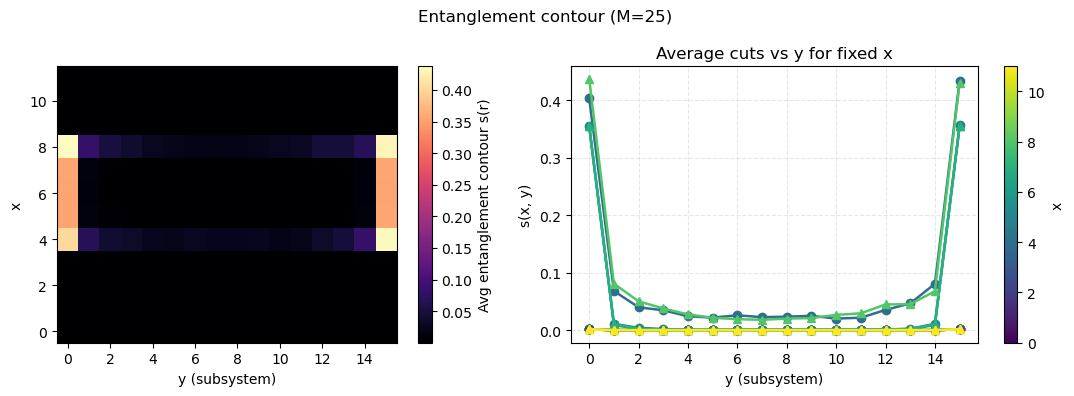

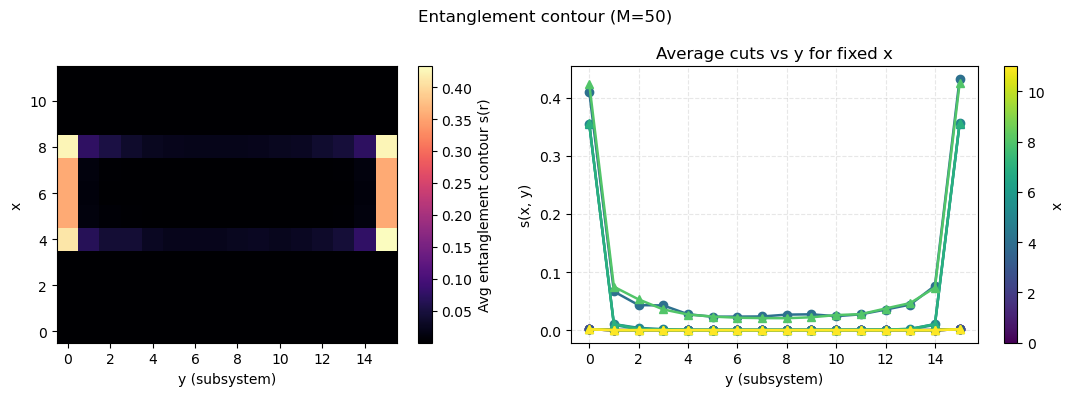

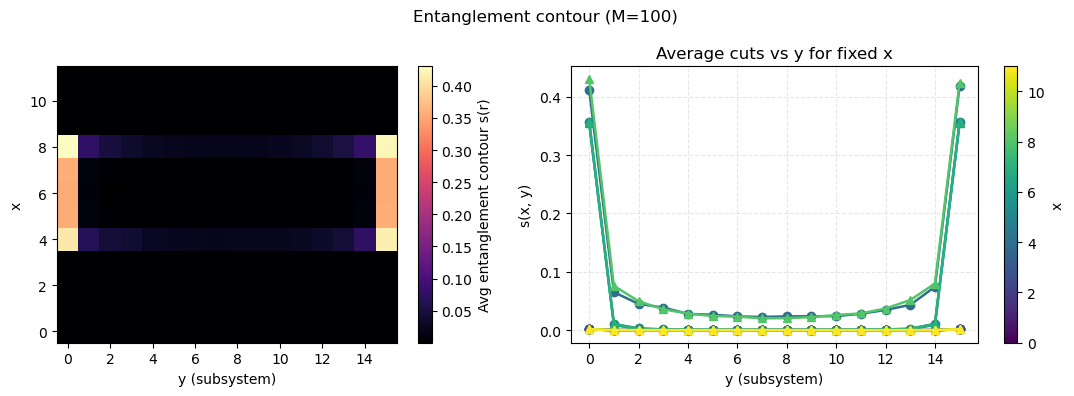

In [5]:
# Heatmap + x-cuts for the sample-averaged entanglement contour
for M in sample_counts:
    s_map_avg, yA = sample_avg_entanglement_contour_batched(G_hist, Nx, Ny, y_cut=Ny // 2, num_samples=M)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.2]})

    vmin = max(np.min(s_map_avg[s_map_avg > 0]), 1e-12)
    vmax = np.max(s_map_avg)
    im = axes[0].imshow(
        s_map_avg,
        origin="lower",
        cmap="magma",
        aspect="auto"
    )
    fig.colorbar(im, ax=axes[0], label="Avg entanglement contour s(r)")
    axes[0].set_xlabel("y (subsystem)")
    axes[0].set_ylabel("x")

    y_vals = np.arange(len(yA))
    x_list = np.arange(Nx)
    colors_x = plt.cm.viridis(np.linspace(0, 1, len(x_list)))
    markers = ["o", "^"]
    for x_idx, color in zip(x_list, colors_x):
        marker = markers[0] if x_idx < Nx // 2 else markers[1]
        axes[1].plot(y_vals, s_map_avg[x_idx, :], marker=marker, color=color, lw=1.8)
    axes[1].set_xlabel("y (subsystem)")
    axes[1].set_ylabel("s(x, y)")
    axes[1].set_title("Average cuts vs y for fixed x")
    axes[1].grid(alpha=0.3, linestyle="--", linewidth=0.8)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=x_list.min(), vmax=x_list.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[1], label="x")

    fig.suptitle(f"Entanglement contour (M={M})")
    plt.tight_layout()
    plt.show()


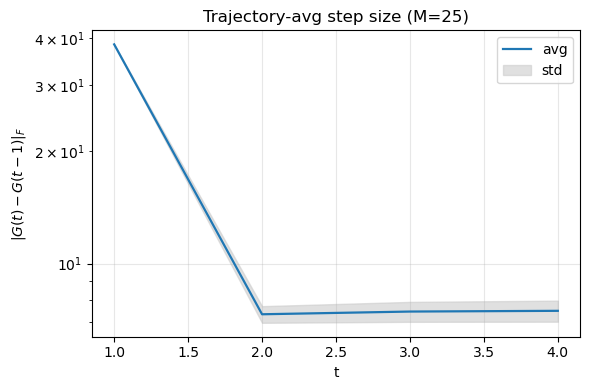

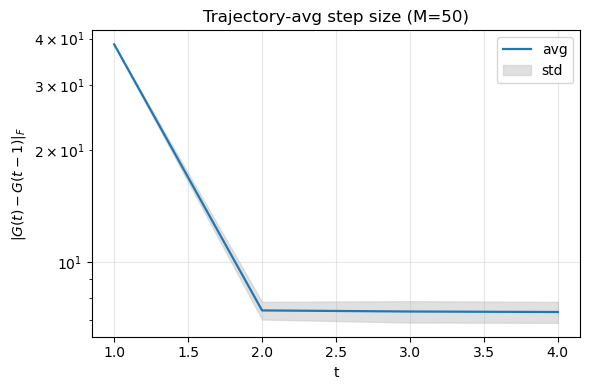

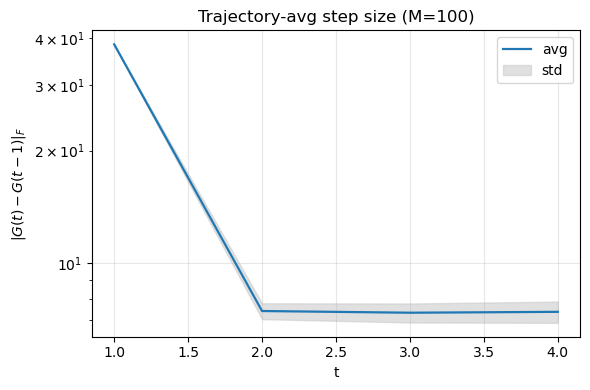

In [6]:
# Trajectory-averaged Frobenius step size: ||G(t) - G(t-1)||_F, averaged over samples.
# This can be expensive; skip if you only want the contour plots.
for M in sample_counts:
    diffs_sum = np.zeros(T - 1, dtype=float)
    diffs_sq_sum = np.zeros(T - 1, dtype=float)

    for s in range(M):
        for t in range(1, T):
            diff = G_hist[s, t] - G_hist[s, t - 1]
            val = np.linalg.norm(diff, ord="fro")
            diffs_sum[t - 1] += val
            diffs_sq_sum[t - 1] += val * val

    diffs_avg = diffs_sum / M
    diffs_std = np.sqrt(np.maximum(diffs_sq_sum / M - diffs_avg**2, 0.0))

    t_vals = np.arange(1, T)
    plt.figure(figsize=(6, 4))
    plt.plot(t_vals, diffs_avg, lw=1.6, label="avg")
    plt.fill_between(t_vals, diffs_avg - diffs_std, diffs_avg + diffs_std, color="0.8", alpha=0.6, label="std")
    plt.xlabel("t")
    plt.ylabel(r"$|G(t)-G(t-1)|_F$")
    plt.yscale("log")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(f"Trajectory-avg step size (M={M})")
    plt.tight_layout()
    plt.show()


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------


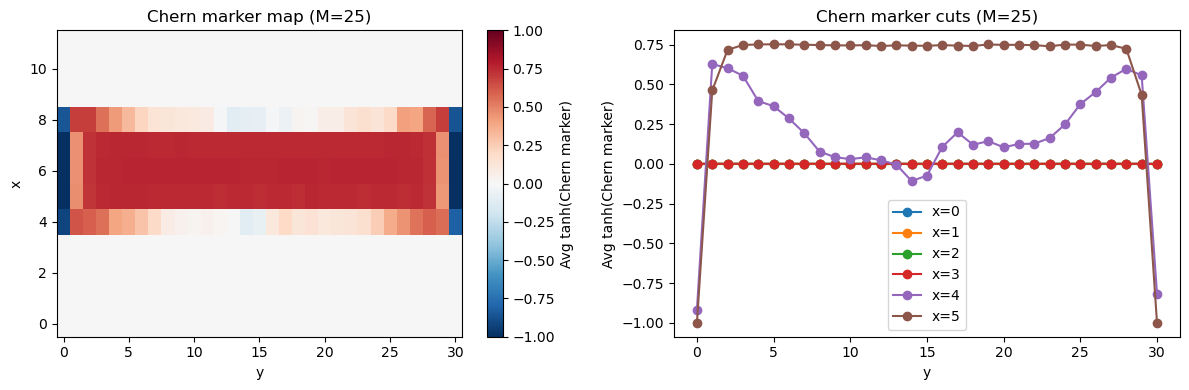

M=25 translation invariance: {'shape_ok': False}


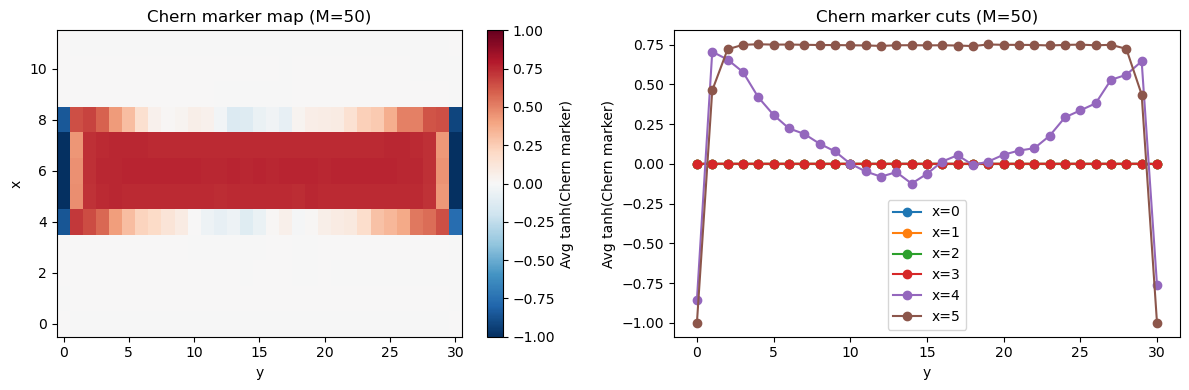

M=50 translation invariance: {'shape_ok': False}


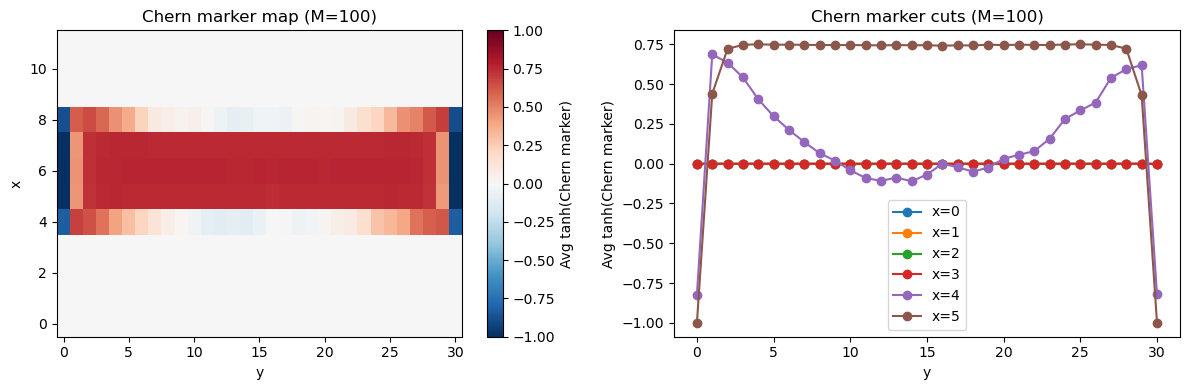

M=100 translation invariance: {'shape_ok': False}


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def local_chern_marker_flat_batch(G_batch, model, batch_size=8):
    """
    Compute local Chern marker for a batch of G matrices.

    G_batch: array-like of shape (S, N, N)
    model: classA_U1FGTN instance
    batch_size: chunk size to limit memory
    Returns: array of shape (S, Nx, Ny)
    """
    G_batch = np.asarray(G_batch)
    S = G_batch.shape[0]
    out = np.zeros((S, model.Nx, model.Ny), dtype=float)

    for i in range(0, S, batch_size):
        j = min(i + batch_size, S)
        for k in range(i, j):
            out[k] = model.local_chern_marker_flat(G_batch[k])

    return out

# Sample-averaged local Chern marker (steady-state per sample)
model = classA_U1FGTN(Nx, Ny, nshell=None, DW=True, alpha_1=1, alpha_2=1)

for M in sample_counts:
    G_ss_batch = np.stack([G_hist[s, -1] for s in range(M)], axis=0)
    chmap_batch = local_chern_marker_flat_batch(G_ss_batch, model, batch_size=8)
    chmap_avg = chmap_batch.mean(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    im = axes[0].imshow(chmap_avg, origin="lower", cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
    fig.colorbar(im, ax=axes[0], label="Avg tanh(Chern marker)")
    axes[0].set_xlabel("y")
    axes[0].set_ylabel("x")
    axes[0].set_title(f"Chern marker map (M={M})")

    for x in range(min(6, Nx)):
        axes[1].plot(chmap_avg[x, :], marker="o", label=f"x={x}")
    axes[1].legend()
    axes[1].set_xlabel("y")
    axes[1].set_ylabel("Avg tanh(Chern marker)")
    axes[1].set_title(f"Chern marker cuts (M={M})")

    plt.tight_layout()
    plt.show()

    print(f"M={M} translation invariance:", model.check_y_translation_invariance(chmap_avg))


In [8]:
# Sample-averaged DW-region Chern sums
for M in sample_counts:
    whole_sum = 0.0
    dw_sum = 0.0
    dw_excl_sum = 0.0
    for s in range(M):
        G_ss = G_hist[s, -1]
        whole_sum += model.sum_chern_marker_dw_region(G_ss, whole_region=True)
        dw_sum += model.sum_chern_marker_dw_region(G_ss, whole_region=False)
        dw_excl_sum += model.sum_chern_marker_dw_region(G_ss, whole_region_except_bndry=True)

    print(f"M={M} Avg Chern number (DW_Region) = {dw_sum / M}")
    print(f"M={M} Avg Chern number (Whole_Region) = {whole_sum / M}")
    print(f"M={M} Avg Chern number (Whole_Region_Except_Boundaries) = {dw_excl_sum / M}")


M=25 Avg Chern number (DW_Region) = 5.305057165458038e-05
M=25 Avg Chern number (Whole_Region) = -7.193057882659559e-10
M=25 Avg Chern number (Whole_Region_Except_Boundaries) = 97.82031749156604


M=50 Avg Chern number (DW_Region) = 5.669520625616542e-05
M=50 Avg Chern number (Whole_Region) = -4.14152800942702e-10
M=50 Avg Chern number (Whole_Region_Except_Boundaries) = 97.54720765519873
M=100 Avg Chern number (DW_Region) = 0.00010025772715383851
M=100 Avg Chern number (Whole_Region) = 3.6180972884380933e-10
M=100 Avg Chern number (Whole_Region_Except_Boundaries) = 97.0024244095524


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- batched contour ---
def entanglement_contour_batch(Gtt_batch, Nx, Ny):
    """
    Gtt_batch: (B, Nlayer, Nlayer)
    Returns: (B, Nx, Ny)
    """
    arr = np.asarray(Gtt_batch, dtype=np.complex128)
    if arr.ndim != 3:
        raise ValueError(f"expected (B,N,N); got {arr.shape}")

    B, Nlayer, _ = arr.shape
    I = np.eye(Nlayer, dtype=np.complex128)
    G2 = 0.5 * (I + arr)

    evals, vecs = np.linalg.eigh(G2)
    evals = np.clip(np.real_if_close(evals), 1e-12, 1 - 1e-12)
    f_eigs = -(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))

    # diag(F) = sum_k f_eigs[k] * |vecs[i,k]|^2
    diagF = np.einsum("bik,bk,bik->bi", vecs, f_eigs, vecs.conj(), optimize=True).real

    diagF = diagF.reshape(B, 2, Nx, Ny, order="F")
    return diagF.sum(axis=1)  # (B, Nx, Ny)

def build_sub_indices(Nx, Ny, y_cut):
    yA = np.arange(y_cut, Ny)
    sub_indices = []
    for y in yA:
        base = 2 * Nx * y
        for x in range(Nx):
            sub_indices.append(base + 2 * x)
            sub_indices.append(base + 2 * x + 1)
    return np.array(sub_indices, dtype=int), len(yA)

def avg_contour_over_samples_batched(G_hist, y_cut_list, num_samples=None):
    if num_samples is None:
        num_samples = G_hist.shape[0]
    num_samples = min(num_samples, G_hist.shape[0])

    Sx_vs_y_cut_sum = np.zeros((len(x_list), len(y_cut_list)), dtype=float)

    # prebuild all sub_indices for each cut
    sub_cache = [build_sub_indices(Nx, Ny, y_cut) for y_cut in y_cut_list]

    for i, (sub_idx, Ny_sub) in enumerate(sub_cache):
        # build batch of G_sub for the first num_samples samples
        G_sub_batch = np.stack(
            [G_hist[s, -1][np.ix_(sub_idx, sub_idx)] for s in range(num_samples)],
            axis=0
        )
        s_batch = entanglement_contour_batch(G_sub_batch, Nx, Ny_sub)  # (M, Nx, Ny_sub)
        Sx_batch = np.sum(s_batch, axis=2)  # (M, Nx)
        Sx_avg = Sx_batch.mean(axis=0)      # (Nx,)

        Sx_vs_y_cut_sum[:, i] = Sx_avg[:len(x_list)]

    return {x: Sx_vs_y_cut_sum[j] for j, x in enumerate(x_list)}

# --- main logic ---
x_list = np.arange(Nx // 2)

y_cut_list_1 = np.arange(2, Ny // 2)
y_cut_list_2 = np.arange(Ny // 2, Ny - 1)

n = min(len(y_cut_list_1), len(y_cut_list_2))
y_cut_list_1 = y_cut_list_1[:n]
y_cut_list_2 = y_cut_list_2[:n]

A_y_list = Ny - y_cut_list_1

def compute_integrated_contour_avgs(num_samples):
    Sx_vs_y_cut_avg_1 = avg_contour_over_samples_batched(G_hist, y_cut_list_1, num_samples=num_samples)
    Sx_vs_y_cut_avg_2 = avg_contour_over_samples_batched(G_hist, y_cut_list_2, num_samples=num_samples)

    Sx_vs_y_cut_avg = {
        x: 0.5 * (Sx_vs_y_cut_avg_1[x] + Sx_vs_y_cut_avg_2[x])
        for x in x_list
    }
    return Sx_vs_y_cut_avg_1, Sx_vs_y_cut_avg_2, Sx_vs_y_cut_avg

integrated_results = {}
for M in sample_counts:
    integrated_results[M] = compute_integrated_contour_avgs(M)


: 

: 

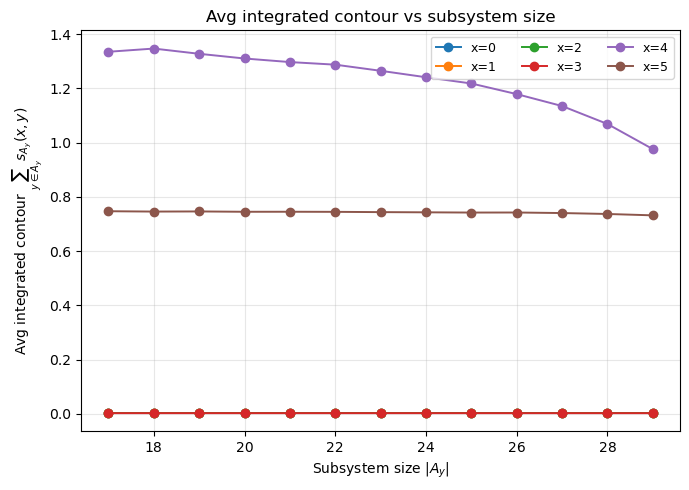

In [ ]:
for M in sample_counts:
    Sx_vs_y_cut_avg_1, Sx_vs_y_cut_avg_2, Sx_vs_y_cut_avg = integrated_results[M]

    plt.figure(figsize=(7, 5))
    for x in x_list:
        plt.plot(A_y_list, Sx_vs_y_cut_avg_1[x], marker='o', lw=1.4, label=f'x={x}, y_cut1')
    plt.xlabel(r'Subsystem size $|A_y|$')
    plt.ylabel(r'Avg integrated contour $\sum_{y \in A_y} s_{A_y}(x,y)$')
    plt.title(f'Avg integrated contour vs subsystem size (M={M})')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.legend(ncol=3, fontsize=9)
    plt.show()


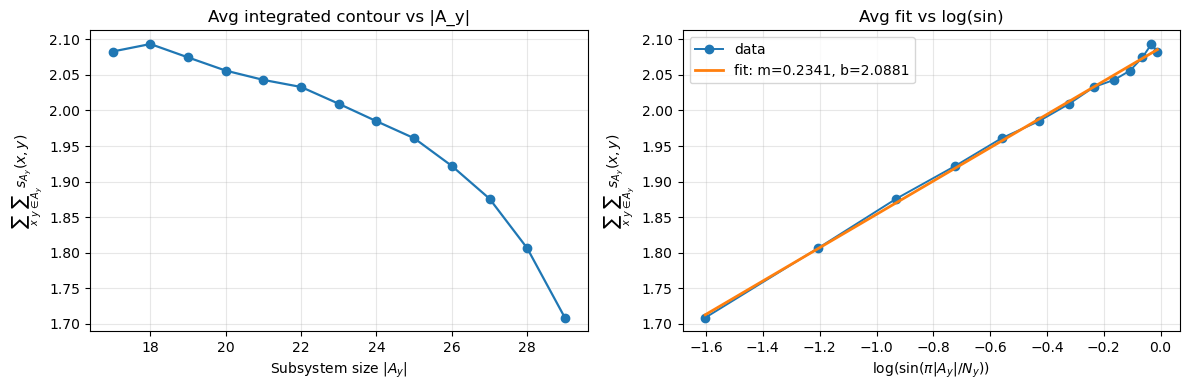

slope = 0.23408845406334933
intercept = 2.088145688255811
R^2 = 0.9977830078745663
adjusted R^2 = 0.9975814631358905
central charge error = 40.4531%


In [ ]:
# Log-sin fit using both cut lists
x0 = model.DW_loc[0]
x_sum_range = np.arange(x0, x0 + 2)

def sum_over_x_for_list(y_cut_list, Sx_vs_y_cut_avg):
    sums = []
    for i in range(len(y_cut_list)):
        total = 0.0
        for x in x_sum_range:
            total += Sx_vs_y_cut_avg[x][i]
        sums.append(total)
    return np.array(sums, dtype=float)

Ay1 = Ny - y_cut_list_1
Ay2 = Ny - y_cut_list_2

for M in sample_counts:
    Sx_vs_y_cut_avg_1, Sx_vs_y_cut_avg_2, Sx_vs_y_cut_avg = integrated_results[M]

    yvals1 = sum_over_x_for_list(y_cut_list_1, Sx_vs_y_cut_avg_1)
    yvals2 = sum_over_x_for_list(y_cut_list_2, Sx_vs_y_cut_avg_2)

    xvals1 = np.log(np.sin(np.pi * Ay1 / Ny))
    xvals2 = np.log(np.sin(np.pi * Ay2 / Ny))

    # combine both datasets
    #xvals = np.concatenate([xvals1, xvals2])
    #yvals = np.concatenate([yvals1, yvals2])
    #Ay = np.concatenate([Ay1, Ay2])
    xvals = xvals1
    yvals = yvals1
    Ay = Ay1

    mask = np.isfinite(xvals)
    x_fit = xvals[mask]
    y_fit = yvals[mask]

    m, b = np.polyfit(x_fit, y_fit, 1)
    y_pred = m * x_fit + b
    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
    r2 = 1 - ss_res / ss_tot
    n = len(y_fit)
    p = 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(Ay, yvals, marker='o', lw=1.6)
    axes[0].set_xlabel(r'Subsystem size $|A_y|$')
    axes[0].set_ylabel(r'$\sum_{x}\sum_{y\in A_y} s_{A_y}(x,y)$')
    axes[0].set_title(f'Avg integrated contour vs |A_y| (M={M})')
    axes[0].grid(alpha=0.3)

    axes[1].plot(x_fit, y_fit, marker='o', lw=1.4, label='data')
    axes[1].plot(x_fit, y_pred, lw=2, label=f'fit: m={m:.4f}, b={b:.4f}')
    axes[1].set_xlabel(r'$\log(\sin(\pi |A_y|/N_y))$')
    axes[1].set_ylabel(r'$\sum_{x}\sum_{y\in A_y} s_{A_y}(x,y)$')
    axes[1].set_title(f'Avg fit vs log(sin) (M={M})')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

    print(f'M={M} slope = {m}')
    print(f'M={M} intercept = {b}')
    print(f'M={M} R^2 = {r2}')
    print(f'M={M} adjusted R^2 = {adj_r2}')
    print(f'M={M} central charge error = {abs(m-1/6)/(1/6)*100:.6g}%')


In [ ]:
print(y_cut_list_1)
print(y_cut_list_2)

[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
[15 16 17 18 19 20 21 22 23 24 25 26 27]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_modular_hamiltonian(G, eps=1e-12):
    G = np.asarray(G, dtype=np.complex128)
    if G.shape[0] != G.shape[1]:
        raise ValueError("G must be square.")

    evals, evecs = np.linalg.eigh(G)
    evals = np.real_if_close(evals, tol=1e-10)
    evals = np.clip(evals, -1 + eps, 1 - eps)

    h_evals = -2.0 * np.arctanh(evals)
    H_mod = (evecs * h_evals[None, :]) @ evecs.conj().T
    return H_mod

def compute_current_density(H_mod, G, Nx, Ny):
    Nx = int(Nx)
    Ny = int(Ny)
    Nlayer = 2 * Nx * Ny

    H_mod = np.asarray(H_mod, dtype=np.complex128)
    G = np.asarray(G, dtype=np.complex128)

    if H_mod.shape != (Nlayer, Nlayer) or G.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected shape ({Nlayer},{Nlayer}) for top-layer input.")

    C = 0.5 * (G + np.eye(Nlayer, dtype=np.complex128))

    H6 = H_mod.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    H6 = np.transpose(H6, (1, 2, 0, 4, 5, 3))

    C6 = C.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    C6 = np.transpose(C6, (1, 2, 0, 4, 5, 3))

    x_idx = np.arange(Nx)[:, None]
    y_idx = np.arange(Ny)[None, :]
    x_next = (x_idx + 1) % Nx
    y_next = (y_idx + 1) % Ny

    Hx = H6[x_idx, y_idx, :, x_next, y_idx, :]
    Cx = C6[x_next, y_idx, :, x_idx, y_idx, :]
    Jx = 2.0 * np.imag(np.sum(Hx * np.swapaxes(Cx, -1, -2), axis=(2, 3)))

    Hy = H6[x_idx, y_idx, :, x_idx, y_next, :]
    Cy = C6[x_idx, y_next, :, x_idx, y_idx, :]
    Jy = 2.0 * np.imag(np.sum(Hy * np.swapaxes(Cy, -1, -2), axis=(2, 3)))

    return Jx.T, Jy.T  # (Ny, Nx)

def plot_modular_current(Jx, Jy, title="Modular Current"):
    Ny, Nx = Jx.shape
    Jx_plot = Jx.T
    Jy_plot = Jy.T

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    im0 = axes[0].imshow(Jx_plot, origin="lower", cmap="RdBu_r", aspect="auto")
    axes[0].set_title("Jx")
    axes[0].set_xlabel("y")
    axes[0].set_ylabel("x")
    fig.colorbar(im0, ax=axes[0], label="Jx")

    im1 = axes[1].imshow(Jy_plot, origin="lower", cmap="RdBu_r", aspect="auto")
    axes[1].set_title("Jy")
    axes[1].set_xlabel("y")
    axes[1].set_ylabel("x")
    fig.colorbar(im1, ax=axes[1], label="Jy")

    if title:
        fig.suptitle(title)
    plt.show()

def plot_modular_quiver(Jx, Jy, title="Modular Current"):
    Ny, Nx = Jx.shape
    Jx_plot = Jx.T
    Jy_plot = Jy.T

    fig, ax = plt.subplots(figsize=(8, 8))
    Y, X = np.meshgrid(np.arange(Ny), np.arange(Nx))
    mag = np.sqrt(Jx_plot**2 + Jy_plot**2)
    q = ax.quiver(Y, X, Jy_plot, Jx_plot, mag, cmap="plasma", pivot="mid")

    ax.set_title(title)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    plt.colorbar(q, ax=ax, label="Current Magnitude")
    plt.show()

def build_sub_indices(Nx, Ny, y_cut):
    yA = np.arange(y_cut, Ny)
    sub_indices = []
    for y in yA:
        base = 2 * Nx * y
        for x in range(Nx):
            sub_indices.append(base + 2 * x)
            sub_indices.append(base + 2 * x + 1)
    return np.array(sub_indices, dtype=int), yA

def sample_avg_modular_current(G_hist, Nx, Ny, y_cut=None, num_samples=None):
    if y_cut is None:
        y_cut = Ny // 2
    if num_samples is None:
        num_samples = G_hist.shape[0]
    num_samples = min(num_samples, G_hist.shape[0])

    sub_indices, yA = build_sub_indices(Nx, Ny, y_cut)
    Ny_sub = len(yA)

    Jx_sum = np.zeros((Ny_sub, Nx), dtype=float)
    Jy_sum = np.zeros((Ny_sub, Nx), dtype=float)

    for s in range(num_samples):
        G_ss = G_hist[s, -1]
        G_sub = G_ss[np.ix_(sub_indices, sub_indices)]

        H_mod = compute_modular_hamiltonian(G_sub)
        Jx, Jy = compute_current_density(H_mod, G_sub, Nx=Nx, Ny=Ny_sub)

        Jx_sum += Jx
        Jy_sum += Jy

    Jx_avg = Jx_sum / num_samples
    Jy_avg = Jy_sum / num_samples
    return Jx_avg, Jy_avg, yA

# ---- usage ----
M = G_hist.shape[0]  # or any smaller number
Jx_avg, Jy_avg, yA = sample_avg_modular_current(G_hist, Nx, Ny, y_cut=Ny // 2, num_samples=M)

plot_modular_current(Jx_avg, Jy_avg, title=f"Modular Current (M={M})")
plot_modular_quiver(Jx_avg, Jy_avg, title=f"Modular Current (M={M})")
